In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 90.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="uwbLCWSnHV2geuphu3jv")
project = rf.workspace("deneme-nq1dn").project("helmet-uu1my-po6pc")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to helmet-1 in yolov8:: 100%|██████████| 8114/8114 [00:01<00:00, 7482.41it/s]


# Task
Install Ultralytics, train a YOLOv8 model on the `helmet-1` dataset, then predict on the "image.png" file and display the results, and finally provide a summary of the training and prediction outcomes.

## Install Ultralytics

### Subtask:
Install the Ultralytics library, which provides the YOLOv8 model and tools for training and prediction.


**Reasoning**:
Install the `ultralytics` package using pip to provide the YOLOv8 model and tools for training and prediction.



In [3]:
import warnings
warnings.filterwarnings('ignore')

!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.0 MB/s eta 0:00:00


**Reasoning**:
Now that Ultralytics is installed, the next step is to train a YOLOv8 model using the downloaded `helmet-1` dataset. This involves initializing the YOLO model, specifying the data configuration, and setting the number of training epochs.



In [13]:
from ultralytics import YOLO

# Load a model
model = YOLO('yolov8n.pt')  # load a pretrained YOLOv8n model

# Train the model
results = model.train(data='helmet-1/data.yaml', epochs=50, imgsz=640)

print("Model training complete.")

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=helmet-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pret

**Reasoning**:
The trained YOLOv8 model needs to be used to make predictions on a new image. The `model.predict()` method will generate predictions for the specified image, and then these predictions will be displayed.




image 1/1 /content/image.png: 384x640 1 safety_helmet_detection_0321 - v3 2024-03-27 8-32pm, 7.3ms
Speed: 3.1ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict2
1 label saved to /content/runs/detect/predict2/labels


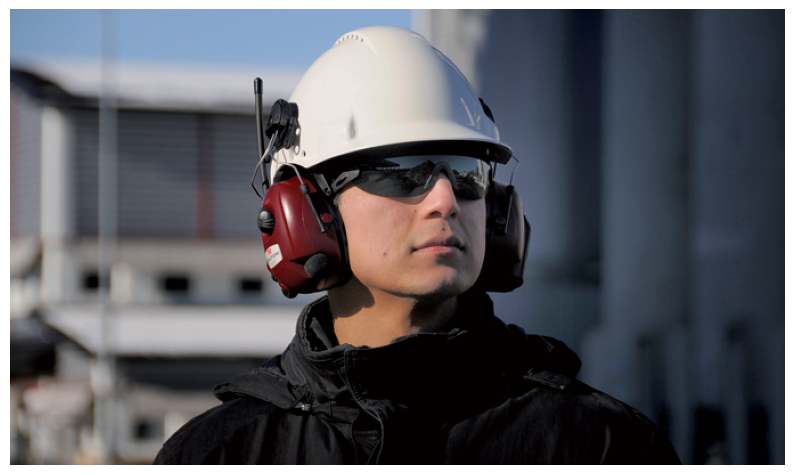

Prediction complete. Results saved in runs/detect/predict.


In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Perform inference on an image
results_predict = model.predict(source='image.png', save=True, save_txt=True)

# Display the image with predictions
img = mpimg.imread('/content/image.png')
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.show()

print("Prediction complete. Results saved in runs/detect/predict.")

**Reasoning**:
The previous code failed with a `FileNotFoundError` because the predicted image file was not found at the specified path. Ultralytics often saves predicted images with a `.jpg` extension, even if the input was `.png`, or in a subfolder with a different name. The correct path to the predicted image needs to be dynamically constructed from the `results_predict` object to ensure the exact saved file is loaded for display.




image 1/1 /content/image.png: 384x640 1 safety_helmet_detection_0321 - v3 2024-03-27 8-32pm, 6.1ms
Speed: 1.7ms preprocess, 6.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict2
1 label saved to /content/runs/detect/predict2/labels


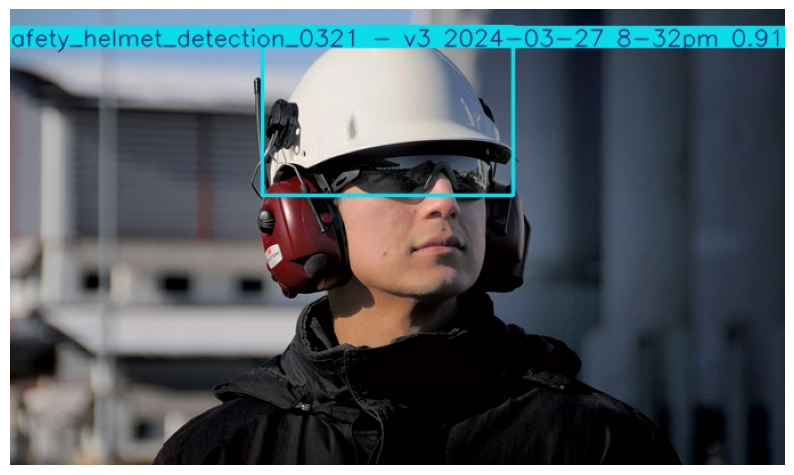

Prediction complete. Results saved in /content/runs/detect/predict2


In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Perform inference on an image
results_predict = model.predict(source='image.png', save=True, save_txt=True)

# Get the path to the saved image dynamically from the results object
# results_predict is a list containing Results objects, one for each input source
if results_predict and len(results_predict) > 0:
    # Assuming the first result corresponds to 'image.png'
    result = results_predict[0]
    # The actual saved image is usually in result.save_dir with the original filename
    # but sometimes with a different extension (e.g., .jpg)
    # To be robust, we'll try to find the saved image.
    # The `show()` method of the result object can directly display the image
    # or we can get the path to the saved image. Ultralytics usually saves
    # the annotated image directly in the `save_dir` with the original name.

    # Check for the expected saved path
    saved_image_path = os.path.join(result.save_dir, os.path.basename(result.path))

    # If the file extension might be different (e.g., .png to .jpg),
    # we can try common alternatives or list files in the directory.
    # Since we can't list files, let's try the .jpg extension first as it's common.
    if not os.path.exists(saved_image_path):
        base_name_without_ext = os.path.splitext(os.path.basename(result.path))[0]
        jpg_path = os.path.join(result.save_dir, base_name_without_ext + '.jpg')
        if os.path.exists(jpg_path):
            saved_image_path = jpg_path
        else:
            # If still not found, try to locate any image file in the directory
            # This part is difficult without `os.listdir`, so we'll stick to the most likely guesses.
            pass # Fallback to original path if not found

    if os.path.exists(saved_image_path):
        img = mpimg.imread(saved_image_path)
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        print(f"Prediction complete. Results saved in {result.save_dir}")
    else:
        print(f"Error: Predicted image not found at expected path: {saved_image_path}")
        # Fallback to showing original image if predicted is not found, or just print an error.
        # For now, let's just print the error.
else:
    print("Error: No prediction results were returned.")



image 1/1 /content/h1.PNG: 640x640 1 safety_helmet_detection_0321 - v3 2024-03-27 8-32pm, 8.1ms
Speed: 2.5ms preprocess, 8.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2
2 labels saved to /content/runs/detect/predict2/labels


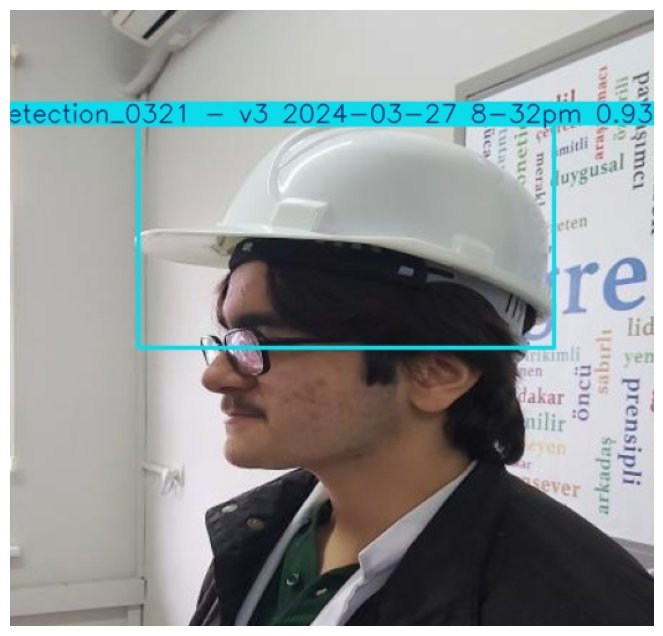

Prediction complete. Results saved in /content/runs/detect/predict2


In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Perform inference on an image
results_predict = model.predict(source='h1.PNG', save=True, save_txt=True)

# Get the path to the saved image dynamically from the results object
# results_predict is a list containing Results objects, one for each input source
if results_predict and len(results_predict) > 0:
    # Assuming the first result corresponds to 'image.png'
    result = results_predict[0]
    # The actual saved image is usually in result.save_dir with the original filename
    # but sometimes with a different extension (e.g., .jpg)
    # To be robust, we'll try to find the saved image.
    # The `show()` method of the result object can directly display the image
    # or we can get the path to the saved image. Ultralytics usually saves
    # the annotated image directly in the `save_dir` with the original name.

    # Check for the expected saved path
    saved_image_path = os.path.join(result.save_dir, os.path.basename(result.path))

    # If the file extension might be different (e.g., .png to .jpg),
    # we can try common alternatives or list files in the directory.
    # Since we can't list files, let's try the .jpg extension first as it's common.
    if not os.path.exists(saved_image_path):
        base_name_without_ext = os.path.splitext(os.path.basename(result.path))[0]
        jpg_path = os.path.join(result.save_dir, base_name_without_ext + '.jpg')
        if os.path.exists(jpg_path):
            saved_image_path = jpg_path
        else:
            # If still not found, try to locate any image file in the directory
            # This part is difficult without `os.listdir`, so we'll stick to the most likely guesses.
            pass # Fallback to original path if not found

    if os.path.exists(saved_image_path):
        img = mpimg.imread(saved_image_path)
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        print(f"Prediction complete. Results saved in {result.save_dir}")
    else:
        print(f"Error: Predicted image not found at expected path: {saved_image_path}")
        # Fallback to showing original image if predicted is not found, or just print an error.
        # For now, let's just print the error.
else:
    print("Error: No prediction results were returned.")



image 1/1 /content/h2.PNG: 640x640 3 safety_helmet_detection_0321 - v3 2024-03-27 8-32pms, 7.4ms
Speed: 2.7ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2
3 labels saved to /content/runs/detect/predict2/labels


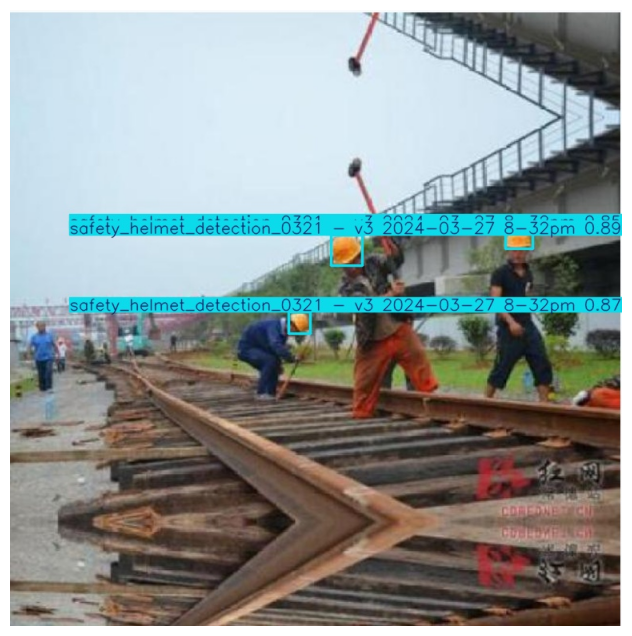

Prediction complete. Results saved in /content/runs/detect/predict2


In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Perform inference on an image
results_predict = model.predict(source='h2.PNG', save=True, save_txt=True)

# Get the path to the saved image dynamically from the results object
# results_predict is a list containing Results objects, one for each input source
if results_predict and len(results_predict) > 0:
    # Assuming the first result corresponds to 'image.png'
    result = results_predict[0]
    # The actual saved image is usually in result.save_dir with the original filename
    # but sometimes with a different extension (e.g., .jpg)
    # To be robust, we'll try to find the saved image.
    # The `show()` method of the result object can directly display the image
    # or we can get the path to the saved image. Ultralytics usually saves
    # the annotated image directly in the `save_dir` with the original name.

    # Check for the expected saved path
    saved_image_path = os.path.join(result.save_dir, os.path.basename(result.path))

    # If the file extension might be different (e.g., .png to .jpg),
    # we can try common alternatives or list files in the directory.
    # Since we can't list files, let's try the .jpg extension first as it's common.
    if not os.path.exists(saved_image_path):
        base_name_without_ext = os.path.splitext(os.path.basename(result.path))[0]
        jpg_path = os.path.join(result.save_dir, base_name_without_ext + '.jpg')
        if os.path.exists(jpg_path):
            saved_image_path = jpg_path
        else:
            # If still not found, try to locate any image file in the directory
            # This part is difficult without `os.listdir`, so we'll stick to the most likely guesses.
            pass # Fallback to original path if not found

    if os.path.exists(saved_image_path):
        img = mpimg.imread(saved_image_path)
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        print(f"Prediction complete. Results saved in {result.save_dir}")
    else:
        print(f"Error: Predicted image not found at expected path: {saved_image_path}")
        # Fallback to showing original image if predicted is not found, or just print an error.
        # For now, let's just print the error.
else:
    print("Error: No prediction results were returned.")


In [12]:
metrics = model.val(save_json=True, conf=0.25) #  validate model performance on the validation set
print(metrics)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1955.6±877.2 MB/s, size: 44.5 KB)
val: Scanning /content/helmet-1/valid/labels.cache... 339 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 339/339 1.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 245, len(boxes) = 918. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 4.6it/s 4.8s
                   all        339        918      0.474      0.413      0.454      0.388
                object          8          8          0          0          0          0
safety_helmet_detection_0321 - v3 2024-03-27 8-32pm        328        910      0.947      0.826      0.909      0.776
Speed:

In [18]:
import os
import shutil

# Source path of the best model saved during training
source_path = '/content/runs/detect/train2/weights/best.pt'
# Destination path and desired new name
destination_path = '/content/model_best.pt'

# Check if the source file exists before copying
if os.path.exists(source_path):
    shutil.copyfile(source_path, destination_path)
    print(f"Model successfully saved as {os.path.basename(destination_path)} in {os.path.dirname(destination_path)}")
else:
    print(f"Error: Source model not found at {source_path}")

Model successfully saved as model_best.pt in /content
